# Analyses v2.2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import analyses.spc as spc
import analyses.linreg as linreg
import analyses.pfr as pfr
import analyses.mwr as mwr 
import analyses.r1_intrusion as r1_intrusion
import analyses.rt_init as rt_init
import analyses.pli_eli as pli_eli
import analyses.irt as irt 
import analyses.tcl as tcl
import analyses.lcrp as lcrp
import analyses.scl as scl
import analyses.statistics as stat_tests
from scipy.stats import wilcoxon
import warnings; warnings.filterwarnings('ignore')
from data.spellcheck import spellcheck_recalls_dl
from data.prolific_quality import filter_sessions_by_quality
from data.recall_inspection import inspect_list_recall

## 0. Load and Clean

In [2]:
# Loads the most recent pulled CSV file from data/data_storage 
data_dir = Path('data/data_storage') # create path to folder 
try:
    data_path = max(data_dir.glob('dirfru_trials*.csv'), key=lambda p: p.stat().st_mtime) # get most recent trial csv
except ValueError:
    raise FileNotFoundError(f'No dirfru_trials*.csv files found in {data_dir}')
raw = pd.read_csv(data_path)
print(f'Loaded {data_path}')

Loaded data\data_storage\dirfru_trials_20260813_084210.csv


In [3]:
# Manual Exclusion
exclude_pid = []
print(f'Before exclusion: {len(raw)} rows')
raw = raw[~raw['prolific_pid'].isin(exclude_pid)].copy()
print(f'After exclusion: {len(raw)} rows')
print(f'Excluded data (Prolific IDs: {exclude_pid})')

Before exclusion: 95425 rows
After exclusion: 95425 rows
Excluded data (Prolific IDs: [])


In [4]:
# Keep only word-presentation and recall rows - analyses.spc_sess / pfr_sess use these
df = raw[raw['type'].isin(['WORD', 'REC_WORD'])].copy()

# Ensure numeric dtypes (raw CSV mixes schemas across rows)
for col in ['serial_position', 'list', 'session', 'l_length', 'rt']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check
type(df['serial_position'].iloc[0]), type(df['list'].iloc[0]), type(df['session'].iloc[0]), type(df['l_length'].iloc[0]), type(df['rt'].iloc[0])

(numpy.float64, numpy.float64, numpy.int64, numpy.int64, numpy.float64)

In [5]:
# Build lookup: presented WORD -> serial position
word_rows = df[df['type'] == 'WORD'].copy()
word_rows['word_key'] = word_rows['word'].str.lower().str.strip()
word_maps = word_rows.set_index(
    ['prolific_pid', 'session', 'list', 'word_key']
)['serial_position'].to_dict()

# recompute serial positions for REC_WORD
def recover_sp(row):
    if row['type'] != 'REC_WORD':
        return row['serial_position']
    if pd.isna(row['rec_word']) or str(row['rec_word']).strip() in ['', 'null']:
        return 99
    key = (row['prolific_pid'], row['session'], row['list'], str(row['rec_word']).lower().strip())
    return word_maps.get(key, 88) # return serial position if found else 88 

df['serial_position'] = df.apply(recover_sp, axis=1)
df = spellcheck_recalls_dl(df) # add spellcheck following original study, Levenshtein dist <= 1 

Damerau-Levenshtein spellcheck corrected 959 recall(s).


In [6]:
df_before_quality = df.copy()
df_after_quality = filter_sessions_by_quality(df_before_quality, raw)

before_sessions = df_before_quality[['prolific_pid', 'session']].drop_duplicates()
after_sessions = df_after_quality[['prolific_pid', 'session']].drop_duplicates()

excluded_sessions = (
    before_sessions
    .merge(after_sessions, on=['prolific_pid', 'session'], how='left', indicator=True)
    .query("_merge == 'left_only'")
    .drop(columns='_merge')
    .sort_values(['prolific_pid', 'session'])
)

excluded = len(excluded_sessions)

print(f"Excluded sessions by quality criteria: {excluded}")
display(excluded_sessions)

df = df_after_quality


Participant 69eb5d9fbfddb861d43a0d0f in session 0 took notes.
Participant 69eb5d9fbfddb861d43a0d0f in session 1 took notes.
Participant stel01 in session 3 had 2 trials with zero correct recalls.
Excluded sessions by quality criteria: 3


,prolific_pid,session
62,69eb5d9fbfddb861d43a0d0f,0
138,69eb5d9fbfddb861d43a0d0f,1
4,stel01,3


## 1. Inspection

In [7]:
df = df[df['study_id'] != 'test']
study_ids = df['study_id'].unique()
print(f"Unique study IDs in the dataset: {study_ids}")

Unique study IDs in the dataset: <StringArray>
['6a2767189a4f0e0a29dc9a32', '6a27672e9f42f5fc0f800c49',
 '6a2768acf487b7842842f74c', '6a276962874a96d003489c45',
 '6a2769b25cbe191d4bf90bba']
Length: 5, dtype: str


In [8]:
# Metadata Inspection
session_info = df[['prolific_pid', 'session', 'initiation_condition']].drop_duplicates(['prolific_pid', 'session'])

# Exclude session 0 before counting toward "included sessions"
included_sessions = session_info[session_info['session'] != 0]

# Count included sessions per participant, keep those with 2+
session_counts = included_sessions.groupby('prolific_pid')['session'].nunique()
twoplus_pids = session_counts[session_counts >= 2].index

# Get one condition label per participant (assumes condition is fixed per participant)
pid_condition = session_info.drop_duplicates('prolific_pid').set_index('prolific_pid')['initiation_condition']

twoplus_conditions = pid_condition.loc[twoplus_pids]

print(f'{len(df)} rows across {session_info["prolific_pid"].nunique()} participants, {len(session_info)} sessions')
print(f"Condition breakdown by session: {session_info['initiation_condition'].value_counts().to_dict()}")
print(f'Participants with 2+ included sessions: {len(twoplus_pids)}')
print(f"Condition breakdown for participants with 2+ included sessions: {twoplus_conditions.value_counts().to_dict()}")

print("Total Sessions Completed:", session_info['session'].nunique())
counts = session_info['session'].value_counts().sort_index()
counts.index = [f"Session {i}" for i in counts.index]
print(counts)

78302 rows across 71 participants, 189 sessions
Condition breakdown by session: {'free': 85, 'primacy': 61, 'recency': 43}
Participants with 2+ included sessions: 37
Condition breakdown for participants with 2+ included sessions: {'free': 16, 'primacy': 12, 'recency': 9}
Total Sessions Completed: 5
Session 0    70
Session 1    47
Session 2    37
Session 3    25
Session 4    10
Name: count, dtype: int64


In [9]:
# Per-Subject Inspection
pid = '69ed087ea53e35cfd772cff2' # (replace with actual Prolific ID of interest)

# 1) Number of sessions completed
n_sessions = session_info[session_info['prolific_pid'] == pid]['session'].nunique()

# 2) Condition per session
print(f"Condition per Session:")
for i in range(n_sessions):
    condition = session_info[(session_info['prolific_pid'] == pid) & (session_info['session'] == i)]['initiation_condition'].iloc[0]
    print(f"Session {i}: {condition}")

# 3) Mean words recalled per list per session
print(f"Mean Words Recalled per Session:")
for i in range(n_sessions):
    data = df_before_quality[(df_before_quality['prolific_pid'] == pid) & (df_before_quality['session'] == i)]
    mean_words = mwr.mwr_sess(data)
    print(f"Session {i}: {mean_words}")

Condition per Session:
Session 0: primacy
Session 1: primacy
Mean Words Recalled per Session:
Session 0: 6.166666666666667
Session 1: 5.916666666666667


In [10]:
# Per-List Inspection
pid = '66c0df877e3dd5e2c1966f18' # (replace with actual Prolific ID of interest)
session = 0
list_num = 5

selected = df.query("prolific_pid == @pid and session == @session and list == @list_num")
condition = selected['initiation_condition'].dropna().iloc[0]
ll = int(selected['l_length'].dropna().iloc[0])
recalls = selected[selected['type'] == 'REC_WORD']['serial_position']
correct_unique = recalls[(recalls >= 1) & (recalls <= ll)].astype(int).nunique()

print(f'Participant {pid}, Session {session}, List {list_num}')
print(f'Initiation direction: {condition}')
print(f'Words recalled: {correct_unique}')
inspect_list_recall(df, pid, session, list_num)

Participant 66c0df877e3dd5e2c1966f18, Session 0, List 5
Initiation direction: primacy
Words recalled: 8


,serial_position,word_shown,recalled_word,recalled_serial_position,intrusion_type
row,,,,,
1,1,sculpture,gift,20,correct
2,2,snack,slide,19,correct
3,3,luggage,actress,18,correct
4,4,drawing,puppy,11,correct
5,5,backbone,france,7,correct
6,6,zebra,zebra,6,correct
7,7,france,sheriff,14,correct
8,8,elbow,loft,10,correct
9,9,eagle,(empty),no response,no response


## T-test for non-random attrition

In [11]:
filtered_p0ids = df[df['session'] == 0]['prolific_pid'].unique()
filtered_p1ids = df[df['session'] == 1]['prolific_pid'].unique()
p0_not_p1 = set(filtered_p0ids) - set(filtered_p1ids)
p0_not_p1_df = df[(df['prolific_pid'].isin(p0_not_p1)) & (df['session'] == 0)]
p0_with_p1_df = df[(df['prolific_pid'].isin(filtered_p1ids)) & (df['session'] == 0)]

In [12]:
mwr_p0notp1 = mwr.mwr(p0_not_p1_df)
mwr_p1plus = mwr.mwr(p0_with_p1_df)

In [13]:
from scipy import stats

mwr_0 = mwr_p0notp1['mwr'].dropna()
mwr_1 = mwr_p1plus['mwr'].dropna()

print(f"n (p0 not p1) = {len(mwr_0)}")
print(f"mean (p0 not p1) = {mwr_0.mean():.3f}")
print(f"n (p1 plus) = {len(mwr_1)}")
print(f"mean (p1 plus) = {mwr_1.mean():.3f}")

t_stat, p_value = stats.ttest_ind(mwr_0, mwr_1, equal_var=False, nan_policy='omit')
print(f"T-statistic = {t_stat:.3f}")
print(f"P-value = {p_value:.4f}")

n (p0 not p1) = 23
mean (p0 not p1) = 7.754
n (p1 plus) = 47
mean (p1 plus) = 7.986
T-statistic = -0.297
P-value = 0.7675


## 2. Demographics


In [14]:
included_pids = df['prolific_pid'].unique()
demog_raw = raw[raw['prolific_pid'].isin(included_pids)].copy()

In [15]:
age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
age_df['age'] = pd.to_numeric(age_df['age'], errors='coerce')
age_df['initiation_condition'] = age_df['prolific_pid'].map(pid_condition)

age_stats = age_df.groupby('initiation_condition')['age'].describe()
age_stats 

,count,mean,std,min,25%,50%,75%,max
initiation_condition,,,,,,,,
free,32.0,25.937500,3.047342,19.0,24.5,26.5,28.00,30.0
primacy,23.0,24.391304,3.070966,20.0,22.0,24.0,27.00,29.0
recency,16.0,25.125000,3.201562,19.0,23.0,25.5,26.75,30.0


In [16]:
gender_map = {
    0: 'Male',
    1: 'Female',
    2: 'Other',
    3: 'Prefer not to answer',
}

gender_df = (
    demog_raw.query("type == 'gender'")[['prolific_pid', 'response']]
    .drop_duplicates('prolific_pid')
    .copy()
)

gender_overrides = {
    '65cb7d52b59b7dd58392e0ba': 'Female'
}

gender_df['gender'] = (
    pd.to_numeric(gender_df['response'], errors='coerce')
    .map(gender_map)
    .fillna('Unknown')
)

gender_df.head(5)

,prolific_pid,response,gender
2323,69cc5b991e26f316db82dd76,1,Female
2585,6a1367055e82b8a9a60fcfa7,1,Female
2842,6a08d4795bc5a7a34e3136d8,0,Male
3082,5e1553fd1e2e58b6448d8dcc,0,Male
3325,699cd71ad2c45e973c440ebe,0,Male


In [17]:
demographics_df = age_df.merge(
    gender_df[['prolific_pid', 'gender']],
    on='prolific_pid',
    how='outer'
)

demographics_df.head(5)

,prolific_pid,age,initiation_condition,gender
0,5834b3f1d6ed08000154eadb,29.0,recency,Other
1,5e0815b567f170172799e072,29.0,primacy,Male
2,5e1553fd1e2e58b6448d8dcc,26.0,free,Male
3,5e8fe87009881f2ee83521fb,26.0,recency,Male
4,5f4dc319c9fb1509b77d8b84,28.0,free,Female


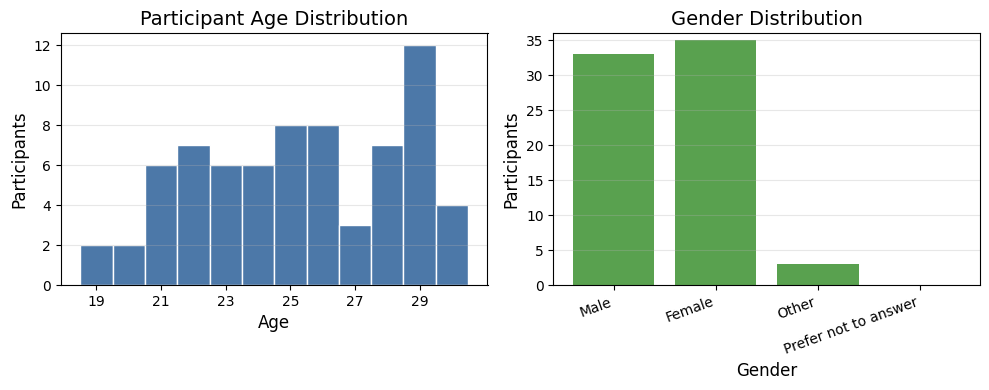

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
bins = np.arange(
    demographics_df['age'].min() - 0.5,
    demographics_df['age'].max() + 1.5,
    1,
)
ax[0].hist(demographics_df['age'].dropna(), bins=bins, color='#4c78a8', edgecolor='white')
ax[0].set_xlabel('Age', fontsize=12)
ax[0].set_ylabel('Participants', fontsize=12)
ax[0].set_title('Participant Age Distribution', fontsize=14)
ax[0].set_xticks(np.arange(demographics_df['age'].min(), demographics_df['age'].max() + 1, 2))
ax[0].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/age_histogram.png', dpi=150)

gender_counts = demographics_df['gender'].value_counts().reindex(gender_map.values(), fill_value=0)
ax[1].bar(gender_counts.index, gender_counts.values, color='#59a14f')
ax[1].set_xlabel('Gender', fontsize=12)
ax[1].set_ylabel('Participants', fontsize=12)
ax[1].set_title('Gender Distribution', fontsize=14)
ax[1].set_ylim(0, max(gender_counts.max() + 1, 1))
ax[1].grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('figures/gender_distribution.png', dpi=150)
plt.show()

## Correct Filtering (FINAL ALGO)

In [19]:
filtered_p0ids = df[df['session'] == 0]['prolific_pid'].unique()
filtered_p1ids = df[df['session'] == 1]['prolific_pid'].unique()
filtered_p2ids = df[df['session'] == 2]['prolific_pid'].unique()
filtered_participants = set(filtered_p0ids) & set(filtered_p1ids) & set(filtered_p2ids)
filtered_df = df[(df['prolific_pid'].isin(filtered_participants)) & (df['session'] >= 1)]
print(filtered_df[filtered_df['session'] == 1]['prolific_pid'].nunique())
print(filtered_df[filtered_df['session'] == 2]['prolific_pid'].nunique())
print(filtered_df[filtered_df['session'] == 3]['prolific_pid'].nunique())
print(filtered_df[filtered_df['session'] == 4]['prolific_pid'].nunique())

36
36
24
10


In [20]:
sessions_1_to_4 = df[df['session'].between(1, 4)]

session_condition_info = sessions_1_to_4[
    sessions_1_to_4['prolific_pid'].isin(filtered_participants)
][['prolific_pid', 'session', 'initiation_condition']].drop_duplicates()

condition_session_counts = (
    session_condition_info
    .groupby(['prolific_pid', 'initiation_condition'], as_index=False)['session']
    .nunique()
)

matching_participant_conditions = condition_session_counts[
    condition_session_counts['session'] >= 2
][['prolific_pid', 'initiation_condition']]

filtered_df_2 = sessions_1_to_4.merge(
    matching_participant_conditions,
    on=['prolific_pid', 'initiation_condition'],
    how='inner',
)

print(f"Participants included: {filtered_df_2['prolific_pid'].nunique()}")
print(f"Sessions included: {filtered_df_2[['prolific_pid', 'session']].drop_duplicates().shape[0]}")
print(
    filtered_df_2[['prolific_pid', 'session', 'initiation_condition']]
    .drop_duplicates()
    .groupby('initiation_condition')['prolific_pid']
    .nunique()
)


Participants included: 36
Sessions included: 106
initiation_condition
free       16
primacy    12
recency     8
Name: prolific_pid, dtype: int64


In [21]:
df_temp = filtered_df[['prolific_pid', 'initiation_condition', 'session']].drop_duplicates()

counts = (
    df_temp.groupby('prolific_pid')['initiation_condition']
    .unique().explode().value_counts()
)

print(counts)

initiation_condition
free       16
primacy    12
recency     8
Name: count, dtype: int64


In [22]:
primacy_df = filtered_df[filtered_df['initiation_condition'] == 'primacy']
primacy_age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
primacy_age = primacy_df[['prolific_pid']].drop_duplicates().merge(primacy_age_df, on='prolific_pid', how='left')['age']
primacy_age.describe()

count    12.00
mean     23.50
std       3.00
min      20.00
25%      21.75
50%      22.50
75%      24.50
max      29.00
Name: age, dtype: float64

In [23]:
recency_df = filtered_df[filtered_df['initiation_condition'] == 'recency']
recency_age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
recency_age = recency_df[['prolific_pid']].drop_duplicates().merge(recency_age_df, on='prolific_pid', how='left')['age']
recency_age.describe()

count     8.000000
mean     26.500000
std       3.295018
min      21.000000
25%      24.500000
50%      27.500000
75%      29.000000
max      30.000000
Name: age, dtype: float64

In [24]:
free_df = filtered_df[filtered_df['initiation_condition'] == 'free']
free_age_df = (
    demog_raw.query("type == 'age'")[['prolific_pid', 'age']]
    .dropna()
    .drop_duplicates('prolific_pid')
)
free_age = free_df[['prolific_pid']].drop_duplicates().merge(free_age_df, on='prolific_pid', how='left')['age']
free_age.describe()

count    16.000000
mean     27.000000
std       2.581989
min      22.000000
25%      25.000000
50%      28.000000
75%      29.000000
max      30.000000
Name: age, dtype: float64

## F7(a-b). Serial Position Curve (SPC)

In [25]:
spc_df = spc.spc_df(filtered_df)
sp_cols = [c for c in spc_df.columns if c.startswith('sp_')]
spc_df.head(5)

,prolific_pid,session,initiation_condition,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,sp_7,...,sp_11,sp_12,sp_13,sp_14,sp_15,sp_16,sp_17,sp_18,sp_19,sp_20
0,5834b3f1d6ed08000154eadb,1,recency,0.500000,0.250000,0.333333,0.250000,0.250000,0.333333,0.333333,...,0.250000,0.083333,0.166667,0.166667,0.250000,0.250000,0.333333,0.583333,1.000000,1.000000
1,5834b3f1d6ed08000154eadb,2,recency,0.333333,0.250000,0.166667,0.166667,0.250000,0.083333,0.083333,...,0.416667,0.333333,0.250000,0.250000,0.333333,0.166667,0.250000,0.666667,1.000000,1.000000
2,5834b3f1d6ed08000154eadb,3,recency,0.416667,0.333333,0.250000,0.166667,0.333333,0.083333,0.083333,...,0.250000,0.250000,0.083333,0.250000,0.166667,0.250000,0.416667,0.416667,0.916667,1.000000
3,5e1553fd1e2e58b6448d8dcc,1,free,0.250000,0.083333,0.250000,0.250000,0.083333,0.250000,0.166667,...,0.333333,0.166667,0.333333,0.166667,0.416667,0.416667,0.666667,0.666667,0.750000,0.916667
4,5e1553fd1e2e58b6448d8dcc,2,free,0.250000,0.166667,0.166667,0.166667,0.250000,0.166667,0.416667,...,0.333333,0.416667,0.416667,0.166667,0.333333,0.250000,0.250000,0.666667,0.916667,0.916667


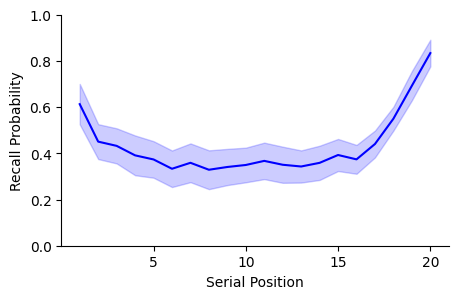

In [26]:
overall_spc = spc.spc_plot_overall(spc_df, path=f'figures/7a_spc_overall.pdf')

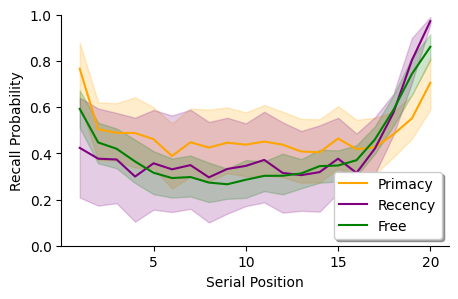

In [27]:
spc_bycond = spc.spc_plot(spc_df, path=f'figures/7b_spc_by_condition.pdf')

In [31]:
participant_curves = spc_df.groupby(['prolific_pid', 'initiation_condition'], as_index=False)[sp_cols].mean()

curves = participant_curves[sp_cols].to_numpy()

left_half = curves[:, :10]
right_half_reversed = curves[:, 10:][:, ::-1]

participant_curves['spc_asymmetry'] = (left_half - right_half_reversed).mean(axis=1)
stat_result = stat_tests.one_sample(participant_curves, ['spc_asymmetry'])
print(stat_result)

  initiation_condition        measure        test   n    t_stat     p_val  \
0              primacy  spc_asymmetry  one_sample  12  0.398317  0.698019   
1              recency  spc_asymmetry  one_sample   8 -2.555029  0.037825   
2                 free  spc_asymmetry  one_sample  16 -3.828185  0.001646   

   dof   cohen_d  p_val_holm  
0   11  0.114984    0.698019  
1    7 -0.903339    0.075650  
2   15 -0.957046    0.004937  


## F7(c): Linear Regression Gradient Trend

In [37]:
linreg_df = spc_df.apply(linreg.prim_rec_lr, axis=1)
linreg_df.head(5)

,prolific_pid,session,initiation_condition,prim_slope,prim_intercept,rec_slope,rec_intercept
0,5834b3f1d6ed08000154eadb,1,recency,-0.050000,0.466667,0.216667,-1.666667e-02
1,5834b3f1d6ed08000154eadb,2,recency,-0.025000,0.308333,0.241667,-1.083333e-01
2,5834b3f1d6ed08000154eadb,3,recency,-0.033333,0.400000,0.200000,-1.110223e-16
3,5e1553fd1e2e58b6448d8dcc,1,free,-0.016667,0.233333,0.108333,3.583333e-01
4,5e1553fd1e2e58b6448d8dcc,2,free,0.000000,0.200000,0.200000,-1.110223e-16


In [38]:
stat_tests.one_sample(linreg_df, ["prim_slope", "rec_slope"])

,initiation_condition,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,primacy,prim_slope,one_sample,12,-2.019581,6.846549e-02,11,-0.583003,6.846549e-02
1,primacy,rec_slope,one_sample,12,3.131820,9.546630e-03,11,0.904078,2.863989e-02
2,recency,prim_slope,one_sample,8,-3.018193,1.943586e-02,7,-1.067092,3.887171e-02
3,recency,rec_slope,one_sample,8,6.477671,3.412334e-04,7,2.290202,1.364933e-03
4,free,prim_slope,one_sample,16,-5.735109,3.944268e-05,15,-1.433777,1.972134e-04
5,free,rec_slope,one_sample,16,11.508076,7.643105e-09,15,2.877019,4.585863e-08


In [39]:
stat_tests.condition_contrast(linreg_df, ["prim_slope", "rec_slope"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,prim_slope,welch,primacy vs free,12,16,12,0.026343,0.979360,13.818284,0.011186,0.979360
1,prim_slope,welch,recency vs free,8,16,8,3.240414,0.003774,21.886524,1.109599,0.022642
2,prim_slope,welch,primacy vs recency,12,8,8,-1.307123,0.215475,12.095212,-0.489538,0.483343
3,rec_slope,welch,primacy vs free,12,16,12,-2.269759,0.037152,16.269729,-0.935530,0.148609
4,rec_slope,welch,recency vs free,8,16,8,1.519210,0.161114,9.545205,0.779532,0.483343
5,rec_slope,welch,primacy vs recency,12,8,8,-2.895198,0.010742,15.629549,-1.309286,0.053711


In [40]:
linreg_df.groupby("prolific_pid")["initiation_condition"].nunique().value_counts()

initiation_condition
1    36
Name: count, dtype: int64

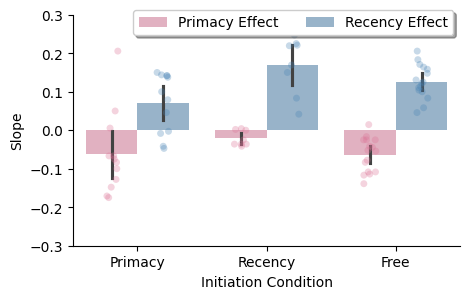

In [41]:
linreg_plot = linreg.plot_linreg(linreg_df, path=f'figures/7c_prim_rec_slopes.pdf')

## F7(d): PFR

In [42]:
pfr_df = pfr.pfr(filtered_df)
pfr_df.head(5)

,prolific_pid,session,initiation_condition,sp_1,sp_2,sp_3,sp_4,sp_5,sp_6,sp_7,...,sp_11,sp_12,sp_13,sp_14,sp_15,sp_16,sp_17,sp_18,sp_19,sp_20
0,5834b3f1d6ed08000154eadb,1,recency,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.000000
1,5834b3f1d6ed08000154eadb,2,recency,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.000000
2,5834b3f1d6ed08000154eadb,3,recency,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,1.000000
3,5e1553fd1e2e58b6448d8dcc,1,free,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.083333,0.0,0.0,0.0,0.000000,0.166667,0.583333,0.083333
4,5e1553fd1e2e58b6448d8dcc,2,free,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.083333,0.000000,0.0,0.0,0.0,0.083333,0.083333,0.666667,0.083333


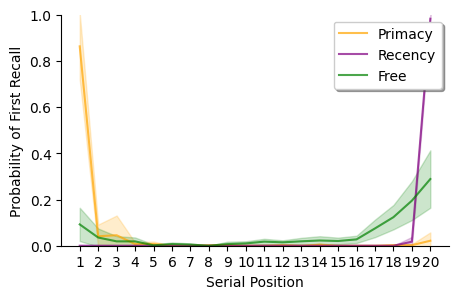

In [43]:
pfr.pfr_plot(pfr_df, path=f'figures/7d_pfr_by_condition.pdf')

In [46]:
# average sessions within participant-condition first
participant_df = (
    pfr_df
    .groupby(["prolific_pid", "initiation_condition"], as_index=False)
    [[f"sp_{i}" for i in range(1, 21)]]
    .mean()
)

# create grouped serial-position bins
participant_df["SP 1-3"] = participant_df[[f"sp_{i}" for i in range(1, 4)]].sum(axis=1)
participant_df["SP 18-20"] = participant_df[[f"sp_{i}" for i in range(18, 21)]].sum(axis=1)

binned_percent = (
    participant_df
    .groupby("initiation_condition")[["SP 1-3", "SP 18-20"]]
    .mean()
    .reset_index()
)

binned_percent

,initiation_condition,SP 1-3,SP 18-20
0,free,0.146583,0.607323
1,primacy,0.949355,0.026235
2,recency,0.000000,1.000000


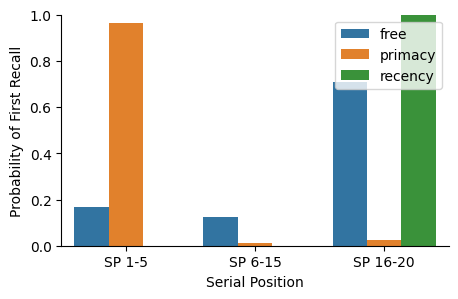

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = binned_percent.melt(
    id_vars="initiation_condition",
    var_name="serial_position_bin",
    value_name="prob_first_recall"
)

plt.figure(figsize=(5, 3))

sns.barplot(
    data=plot_df,
    x="serial_position_bin",
    y="prob_first_recall",
    hue="initiation_condition",
)

plt.xlabel("Serial Position")
plt.ylabel("Probability of First Recall")
plt.ylim(0, 1)
plt.legend(loc='upper right')
sns.despine()
plt.show()


## F8(a-b): Mean words recalled

For each session, `mwr_sess` returns the average number of correct recalls
per list.

In [53]:
mwr_df = mwr.mwr(filtered_df)
mwr_df.head(5)

,prolific_pid,session,initiation_condition,mwr
0,5834b3f1d6ed08000154eadb,1,recency,7.250000
1,5834b3f1d6ed08000154eadb,2,recency,6.333333
2,5834b3f1d6ed08000154eadb,3,recency,6.916667
3,5e1553fd1e2e58b6448d8dcc,1,free,6.916667
4,5e1553fd1e2e58b6448d8dcc,2,free,7.166667


In [56]:
stat_tests.condition_contrast(mwr_df, ["mwr"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,mwr,welch,primacy vs free,12,16,12,1.175003,0.255934,17.277212,0.479087,0.767801
1,mwr,welch,recency vs free,8,16,8,0.037328,0.971085,8.510489,0.020414,1.000000
2,mwr,welch,primacy vs recency,12,8,8,0.654517,0.525146,11.979659,0.318154,1.000000


In [60]:
mwr_sess = mwr_df[mwr_df['session'] == 4]
stat_tests.condition_contrast(mwr_sess, ["mwr"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,mwr,welch,primacy vs free,3,5,3,-1.128746,0.302175,5.989769,-0.699882,0.906525
1,mwr,welch,recency vs free,2,5,2,0.220812,0.859606,1.077665,0.302515,1.000000
2,mwr,welch,primacy vs recency,3,2,2,-0.487416,0.709057,1.035183,-0.586941,1.000000


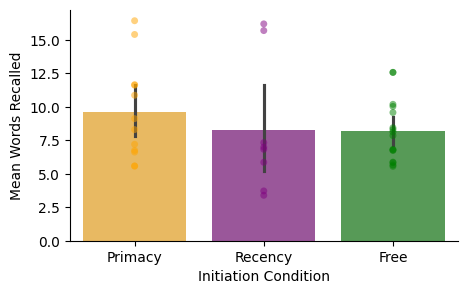

In [ ]:
mwr.mwr_plot(mwr_df, path=f'figures/8a_mwr_by_condition.pdf')

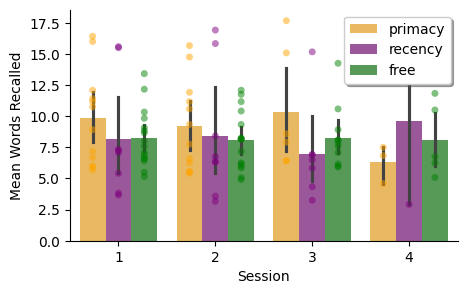

In [52]:
mwr.mwr_plot_by_session(mwr_df, path=f'figures/8b_mwr_by_condition_by_session.pdf')

## F9(a-b) R1 Intrusion Probability

In [61]:
r1_intrusion_data = r1_intrusion.r1_intrusion_df(filtered_df)
r1_intrusion_data.head(5)

,prolific_pid,session,initiation_condition,prop_wrong
0,5834b3f1d6ed08000154eadb,1,recency,0.0
1,5834b3f1d6ed08000154eadb,2,recency,0.0
2,5834b3f1d6ed08000154eadb,3,recency,0.0
3,5e1553fd1e2e58b6448d8dcc,1,free,0.0
4,5e1553fd1e2e58b6448d8dcc,2,free,0.0


In [62]:
summary = (
    r1_intrusion_data
    .groupby("initiation_condition")["prop_wrong"]
    .agg(mean="mean", sd="std")
)

print(summary)

                          mean        sd
initiation_condition                    
free                  0.031250  0.061080
primacy               0.121671  0.133733
recency               0.030000  0.040825


In [63]:
stat_tests.condition_contrast(r1_intrusion_data, ["prop_wrong"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,prop_wrong,welch,primacy vs free,12,16,12,2.631051,0.019676,14.076264,1.113355,0.041038
1,prop_wrong,welch,recency vs free,8,16,8,-0.344535,0.733723,21.950235,-0.121339,0.733723
2,prop_wrong,welch,primacy vs recency,12,8,8,2.865397,0.013679,12.535610,1.079145,0.041038


In [97]:
for sess in range(1,5):
    r1_intrusion_prim = r1_intrusion_data[(r1_intrusion_data['session'] == sess) & (r1_intrusion_data['initiation_condition'] == 'primacy')]['prop_wrong'].mean()
    print(f'Session {sess} - Primacy: = {r1_intrusion_prim:.3f}')
    r1_intrusion_rec = r1_intrusion_data[(r1_intrusion_data['session'] == sess) & (r1_intrusion_data['initiation_condition'] == 'recency')]['prop_wrong'].mean()
    print(f'Session {sess} - Recency: = {r1_intrusion_rec:.3f}')

Session 1 - Primacy: = 0.000
Session 1 - Recency: = 0.000
Session 2 - Primacy: = nan
Session 2 - Recency: = nan
Session 3 - Primacy: = nan
Session 3 - Recency: = nan
Session 4 - Primacy: = nan
Session 4 - Recency: = nan


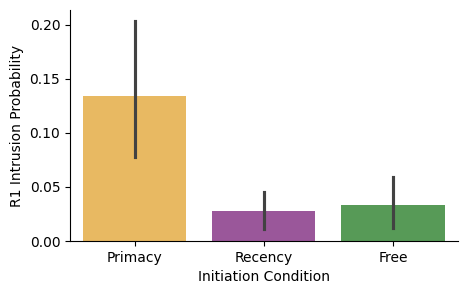

In [64]:
r1_intrusion.r1_intrusion_overall(r1_intrusion_data, path=f'figures/9a_r1_intrusion_overall.pdf')

## F9(c) R1 Response Time

In [65]:
rt_init_df = rt_init.rt_init_df(filtered_df)
rt_init_df.head(5)

,prolific_pid,session,initiation_condition,rt_initial
0,5834b3f1d6ed08000154eadb,1,recency,1340.325000
1,5834b3f1d6ed08000154eadb,2,recency,1180.466667
2,5834b3f1d6ed08000154eadb,3,recency,1452.483333
3,5e1553fd1e2e58b6448d8dcc,1,free,1227.758333
4,5e1553fd1e2e58b6448d8dcc,2,free,1235.558333


In [66]:
rt_init_df.groupby("initiation_condition")["rt_initial"].agg(mean="mean", sd="std")

,mean,sd
initiation_condition,,
free,1755.649885,2121.900197
primacy,3097.482811,1859.025107
recency,1604.991273,1133.462614


In [67]:
stat_tests.condition_contrast(rt_init_df, ["rt_initial"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,rt_initial,welch,primacy vs free,12,16,12,1.692907,0.102544,25.741143,0.610908,0.205087
1,rt_initial,welch,recency vs free,8,16,8,-0.526110,0.604167,21.623153,-0.177734,0.604167
2,rt_initial,welch,primacy vs recency,12,8,8,2.833076,0.011041,17.962988,1.177916,0.033124


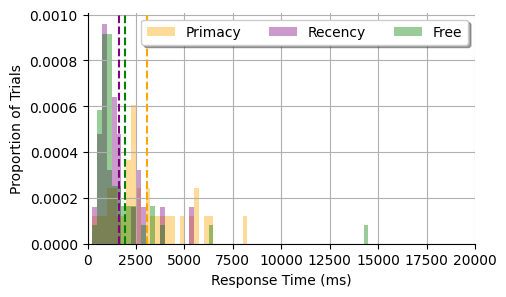

In [68]:
rt_init_plot = rt_init.rt_init_plot(rt_init_df, path=f'figures/9b_rt_init.pdf')

## F10(A-B) PLIs and ELIs

In [89]:
import importlib
importlib.reload(pli_eli)

<module 'analyses.pli_eli' from 'c:\\Users\\andre\\RecallInitiation2026\\analyses\\pli_eli.py'>

In [90]:
plieli_df = pli_eli.intrusion_rates(filtered_df)
plieli_df.head(10)

,prolific_pid,session,initiation_condition,eli,pli
0,5834b3f1d6ed08000154eadb,1,recency,0.250000,0.125000
1,5834b3f1d6ed08000154eadb,2,recency,0.250000,0.000000
2,5834b3f1d6ed08000154eadb,3,recency,0.083333,0.000000
3,5e1553fd1e2e58b6448d8dcc,1,free,1.083333,0.250000
4,5e1553fd1e2e58b6448d8dcc,2,free,1.166667,0.625000
5,5e1553fd1e2e58b6448d8dcc,3,free,1.181818,0.571429
6,5e1553fd1e2e58b6448d8dcc,4,free,0.600000,0.166667
7,5f4dc319c9fb1509b77d8b84,1,free,0.333333,0.125000
8,5f4dc319c9fb1509b77d8b84,2,free,0.500000,0.428571
9,5f4dc319c9fb1509b77d8b84,3,free,0.583333,0.000000


In [91]:
plieli_recency = plieli_df[plieli_df['initiation_condition']=='recency']
plieli_recency_eli = plieli_recency['eli'].tolist()
print(f"Recency ELI: {np.mean(plieli_recency_eli)}")
plieli_recency_pli = plieli_recency['pli'].tolist()
print(f"Recency PLI: {np.mean(plieli_recency_pli)}")

plieli_primacy = plieli_df[plieli_df['initiation_condition']=='primacy']
plieli_primacy_eli = plieli_primacy['eli'].tolist()
print(f"Primacy ELI: {np.mean(plieli_primacy_eli)}")
plieli_primacy_pli = plieli_primacy['pli'].tolist()
print(f"Primacy PLI: {np.mean(plieli_primacy_pli)}")


Recency ELI: 0.5330303030303031
Recency PLI: 0.15071428571428572
Primacy ELI: 1.253917967554331
Primacy PLI: 0.34108946608946605


In [92]:
stat_tests.condition_contrast(plieli_df, ['pli','eli'], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,pli,welch,primacy vs free,12,16,12,1.514309,0.146900,18.440247,0.610163,0.511080
1,pli,welch,recency vs free,8,16,8,-0.954127,0.353328,17.081433,-0.384505,0.706656
2,pli,welch,primacy vs recency,12,8,8,2.168105,0.044109,17.614386,0.885427,0.264653
3,eli,welch,primacy vs free,12,16,12,1.772845,0.102484,11.600629,0.778419,0.511080
4,eli,welch,recency vs free,8,16,8,-0.213745,0.835414,9.187671,-0.111914,0.835414
5,eli,welch,primacy vs recency,12,8,8,1.744033,0.102216,14.562552,0.674212,0.511080


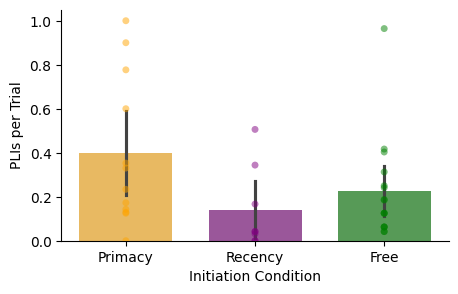

In [93]:
pli_eli.pli_plot_overall(plieli_df, path=f'figures/10a_pli.pdf')

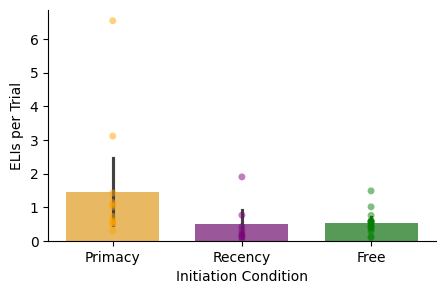

In [94]:
pli_eli.eli_plot_overall(plieli_df, path=f'figures/10b_eli.pdf')

In [84]:
for sess in range(1,5):
    plieli_sess = plieli_df[plieli_df['session']==sess]
    print(f'Session {sess}')
    print(stat_tests.condition_contrast(plieli_sess, ['pli','eli'], paired=False))

Session 1
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     pli  welch     primacy vs free   12   16  12  3.017537  0.009469   
1     pli  welch     recency vs free    8   16   8 -1.141937  0.268802   
2     pli  welch  primacy vs recency   12    8   8  3.529382  0.003343   
3     eli  welch     primacy vs free   12   16  12  1.796664  0.098147   
4     eli  welch     recency vs free    8   16   8  0.209209  0.839290   
5     eli  welch  primacy vs recency   12    8   8  1.460624  0.162559   

         dof   cohen_d  p_val_holm  
0  13.616878  1.284774    0.047347  
1  17.572820 -0.455224    0.537605  
2  13.973649  1.353831    0.020061  
3  11.737674  0.787041    0.392590  
4   8.365602  0.115609    0.839290  
5  16.808909  0.584751    0.487676  
Session 2
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     pli  welch     primacy vs free   12   16  12  0.015757  0.987552   
1     pli  welch     recency vs free    8   16   8 -1.

## F10(C): Final IRTs

In [85]:
irt_final_df = irt.irt_final_df(filtered_df, n_final=4)
irt_final_df.head(5)

,prolific_pid,session,initiation_condition,relative_output_position,irt
0,5834b3f1d6ed08000154eadb,1,recency,-4.0,4392.830000
1,5834b3f1d6ed08000154eadb,1,recency,-3.0,3332.825000
2,5834b3f1d6ed08000154eadb,1,recency,-2.0,4270.333333
3,5834b3f1d6ed08000154eadb,1,recency,-1.0,13346.966667
4,5834b3f1d6ed08000154eadb,1,recency,0.0,11489.550000


In [86]:
for pos in range(0,5):
    print(f'Position -{pos}')
    print(stat_tests.condition_contrast(irt_final_df[irt_final_df['relative_output_position']==-1*pos], ['irt'], paired=False))

Position -0
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     irt  welch     primacy vs free   12   16  12 -1.149728  0.260723   
1     irt  welch     recency vs free    8   16   8 -0.508599  0.616700   
2     irt  welch  primacy vs recency   12    8   8 -0.627119  0.539413   

         dof   cohen_d  p_val_holm  
0  25.999147 -0.420238    0.782168  
1  19.636527 -0.193670    1.000000  
2  16.027470 -0.281322    1.000000  
Position -1
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     irt  welch     primacy vs free   12   16  12 -0.370614  0.714440   
1     irt  welch     recency vs free    8   16   8  0.418354  0.682857   
2     irt  welch  primacy vs recency   12    8   8 -0.709664  0.496982   

         dof   cohen_d  p_val_holm  
0  22.184376 -0.128453         1.0  
1  12.374624  0.190708         1.0  
2   8.469979 -0.378897         1.0  
Position -2
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \


In [87]:
summary = (
    irt_final_df
    .groupby(["initiation_condition", "relative_output_position"])["irt"]
    .agg(mean="mean", sd="std")
    .reset_index()
)

print(summary)

   initiation_condition  relative_output_position         mean           sd
0                  free                      -4.0  2831.573462  1165.359072
1                  free                      -3.0  3291.271389  1248.688865
2                  free                      -2.0  3963.106837  1948.088137
3                  free                      -1.0  4782.614167  2455.677776
4                  free                       0.0  8290.587105  5367.829494
5               primacy                      -4.0  3449.241221  1108.131407
6               primacy                      -3.0  3729.800456  1391.766494
7               primacy                      -2.0  3798.358457  1365.102021
8               primacy                      -1.0  4345.981175  1231.555264
9               primacy                       0.0  6222.548072  4723.741496
10              recency                      -4.0  3425.738754  1543.545651
11              recency                      -3.0  3966.223407  1594.606350
12          

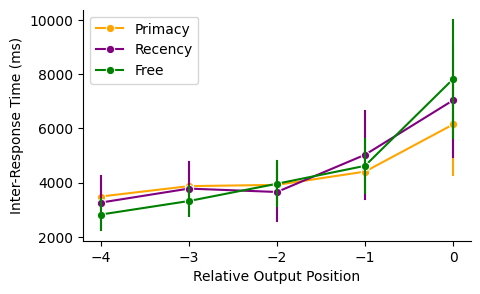

In [88]:
irt.irt_final_plot(irt_final_df, 5, path=f'figures/10c_irt_final.pdf')

In [95]:
irt_tot_df = irt.irt_tot_df(filtered_df)
irt_tot_df.head(5)

,prolific_pid,session,initiation_condition,ncr,ncr_bin,total_irt,irt_h1,irt_h2,irt_delta
0,5834b3f1d6ed08000154eadb,1,recency,6,3,23044.433333,11953.133333,11091.30,-861.833333
1,5834b3f1d6ed08000154eadb,1,recency,7,3,24773.950000,6805.950000,15511.05,8705.100000
2,5834b3f1d6ed08000154eadb,1,recency,8,4,56129.200000,12867.300000,43261.90,30394.600000
3,5834b3f1d6ed08000154eadb,1,recency,9,4,42049.000000,12027.400000,26605.95,14578.550000
4,5834b3f1d6ed08000154eadb,2,recency,4,2,10262.600000,7841.700000,2420.90,-5420.800000


In [96]:
for bin in range(1, 11):
    print(f'NCR Bin {bin}')
    print(stat_tests.condition_contrast(irt_tot_df[irt_tot_df['ncr_bin']==bin], ['irt_delta'], paired=False))

NCR Bin 1
     measure   test            contrast  n_1  n_2  n    t_stat     p_val  \
0  irt_delta  welch     primacy vs free    4    3  3  0.163341  0.878894   
1  irt_delta  welch     recency vs free    2    3  2 -1.412497  0.266669   
2  irt_delta  welch  primacy vs recency    4    2  2  2.226576  0.090187   

        dof   cohen_d  p_val_holm  
0  3.647848  0.130690    0.878894  
1  2.572469 -1.049381    0.533339  
2  3.986130  1.464617    0.270561  
NCR Bin 2
     measure   test            contrast  n_1  n_2  n    t_stat     p_val  \
0  irt_delta  welch     primacy vs free    8   13  8  0.046698  0.963259   
1  irt_delta  welch     recency vs free    5   13  5 -2.761395  0.014086   
2  irt_delta  welch  primacy vs recency    8    5  5  2.996006  0.013374   

         dof   cohen_d  p_val_holm  
0  18.313520  0.019424    0.963259  
1  15.703067 -0.968396    0.040121  
2  10.043393  1.430453    0.040121  
NCR Bin 3
     measure   test            contrast  n_1  n_2  n    t_stat     p

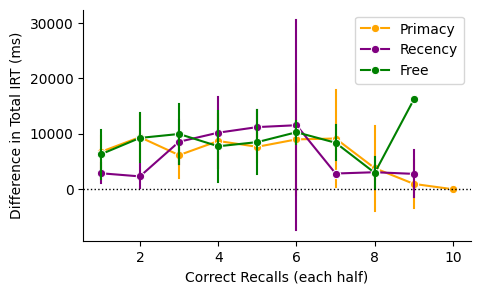

In [97]:
irt.irt_tot_plot(irt_tot_df, path=f'figures/10e_irt_total.pdf')

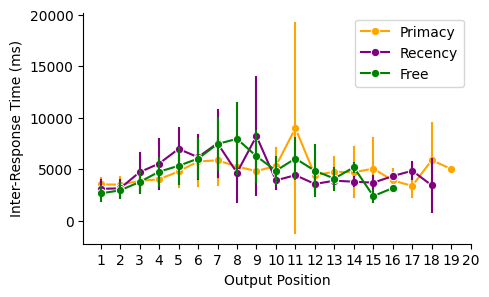

In [99]:
irt_first_df = irt.irt_first_df(filtered_df, n_first=20)
irt.irt_first_plot(irt_first_df, n_first=20, path=f'figures/10d_irt_first.pdf')

In [100]:
for pos in range(1, 21):
    print(f'Output Position {pos}')
    print(stat_tests.condition_contrast(irt_first_df[irt_first_df['output_position']==pos], ['irt'], paired=False))

Output Position 1
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     irt  welch     primacy vs free   12   16  12  1.851241  0.075555   
1     irt  welch     recency vs free    8   16   8  0.756392  0.460285   
2     irt  welch  primacy vs recency   12    8   8  0.815172  0.429669   

         dof   cohen_d  p_val_holm  
0  25.933943  0.672537    0.226666  
1  16.182338  0.311080    0.859337  
2  12.988630  0.388053    0.859337  
Output Position 2
  measure   test            contrast  n_1  n_2   n    t_stat     p_val  \
0     irt  welch     primacy vs free   12   16  12  1.036669  0.309652   
1     irt  welch     recency vs free    8   16   8  0.349661  0.730706   
2     irt  welch  primacy vs recency   12    8   8  0.637308  0.532794   

         dof   cohen_d  p_val_holm  
0  25.420262  0.387328    0.928955  
1  17.755079  0.138834    1.000000  
2  16.262834  0.284483    1.000000  
Output Position 3
  measure   test            contrast  n_1  n_2   n    t_

## F11(A-B). Temporal clustering score

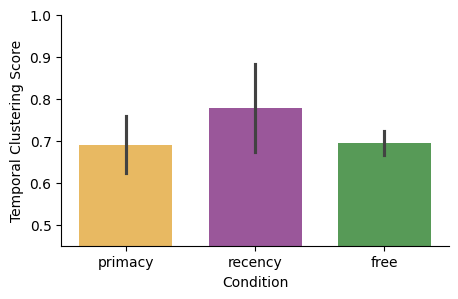

In [101]:
tcl_df = tcl.tcl(filtered_df)
tcl.plot_tcl(tcl_df, path="figures/11a_tcl_overall.pdf")

In [102]:
stat_tests.condition_contrast(tcl_df, ['tcl'], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,tcl,welch,primacy vs free,12,16,12,-0.097117,0.923913,15.071982,-0.040586,0.923913
1,tcl,welch,recency vs free,8,16,8,1.481152,0.176293,8.120097,0.833891,0.528878
2,tcl,welch,primacy vs recency,12,8,8,-1.346582,0.201579,12.742153,-0.644219,0.528878


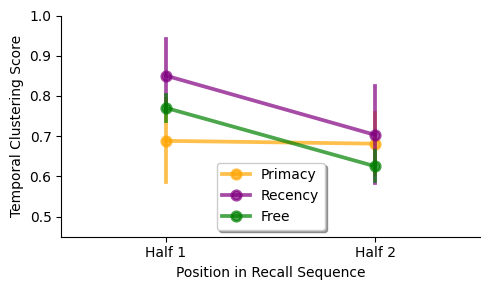

In [103]:
tcl_h_df = tcl.tcl_h(filtered_df)
tcl.plot_tcl_h(tcl_h_df, path="figures/11b_tcl_half.pdf")

In [104]:
stat_tests.condition_contrast(tcl_h_df, ['tcl_h1', 'tcl_h2', 'tcl_delta'], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,tcl_h1,welch,primacy vs free,12,16,12,-1.487741,0.160481,13.105263,-0.637997,0.816714
1,tcl_h1,welch,recency vs free,8,16,8,1.640671,0.136119,8.782984,0.880860,0.816714
2,tcl_h1,welch,primacy vs recency,12,8,8,-2.317226,0.032582,17.848605,-0.987908,0.293240
3,tcl_h2,welch,primacy vs free,12,16,12,1.305498,0.209733,16.407954,0.537270,0.838933
4,tcl_h2,welch,recency vs free,8,16,8,1.210939,0.258878,8.401885,0.667401,0.838933
5,tcl_h2,welch,primacy vs recency,12,8,8,-0.299030,0.769877,12.380972,-0.144126,1.000000
6,tcl_delta,welch,primacy vs free,12,16,12,2.273435,0.039185,14.074629,0.962047,0.313483
7,tcl_delta,welch,recency vs free,8,16,8,-0.057289,0.955132,13.860161,-0.024973,1.000000
8,tcl_delta,welch,primacy vs recency,12,8,8,2.170086,0.045243,16.158474,0.858726,0.316699


## F11(C) Lag-CRP

Lag-CRP is computed per session, then averaged within participant-condition
before plotting condition curves.


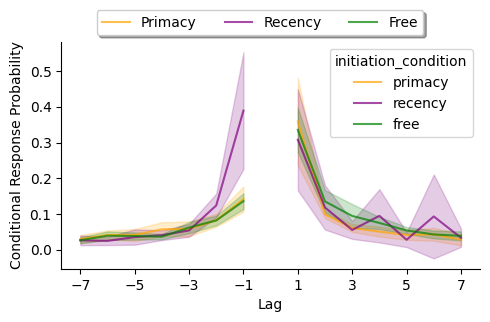

In [105]:
lcrp_df = lcrp.lag_crp(filtered_df)
lcrp.plot_lcrp(lcrp_df, max_lag = 7, path='figures/11c_lcrp.pdf')

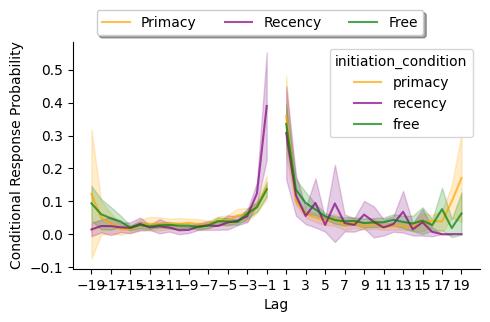

In [106]:
lcrp.plot_lcrp(lcrp_df, max_lag = 19, path='figures/11e_lcrp_full.pdf')

In [107]:
fwd_asym_df = lcrp_df.apply(lambda row: lcrp.forward_asymmetry(row, n=1), axis=1)

stat_tests.condition_contrast(fwd_asym_df, ["asym"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,asym,welch,primacy vs free,12,16,12,0.265739,0.793521,17.640061,0.107944,0.793521
1,asym,welch,recency vs free,8,16,8,-2.514372,0.034958,8.352114,-1.390823,0.095405
2,asym,welch,primacy vs recency,12,8,8,2.449928,0.031802,11.253090,1.210292,0.095405


In [108]:
stat_tests.condition_contrast(lcrp_df, ["lp_1", "ln_1"], paired=False)


,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,lp_1,welch,primacy vs free,12,16,12,0.338114,0.739530,16.541087,0.138947,1.000000
1,lp_1,welch,recency vs free,8,16,8,-0.346519,0.736309,9.757550,-0.175817,1.000000
2,lp_1,welch,primacy vs recency,12,8,8,0.533771,0.600946,15.764997,0.240732,1.000000
3,ln_1,welch,primacy vs free,12,16,12,0.271526,0.788889,19.170231,0.108624,1.000000
4,ln_1,welch,recency vs free,8,16,8,3.014023,0.018726,7.258240,1.835557,0.112355
5,ln_1,welch,primacy vs recency,12,8,8,-2.905176,0.020679,7.658936,-1.599337,0.112355


In [109]:
tmp = stat_tests.participant_condition_mean(lcrp_df, ["lp_1", "ln_1"])

tmp.groupby("initiation_condition")[["lp_1", "ln_1"]].agg(["mean", "sem", "count"])

stat_tests.condition_contrast(fwd_asym_df, ["asym"], paired=False)


,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,asym,welch,primacy vs free,12,16,12,0.265739,0.793521,17.640061,0.107944,0.793521
1,asym,welch,recency vs free,8,16,8,-2.514372,0.034958,8.352114,-1.390823,0.095405
2,asym,welch,primacy vs recency,12,8,8,2.449928,0.031802,11.253090,1.210292,0.095405


## F11(d) Semantic Clustering

In [110]:
wordpool = list(np.loadtxt('data/wordpool/wordpool_ltpFR3.txt', dtype=str))
w2v_scores = np.loadtxt('data/wordpool/w2v_scores_ltpFR3.txt')

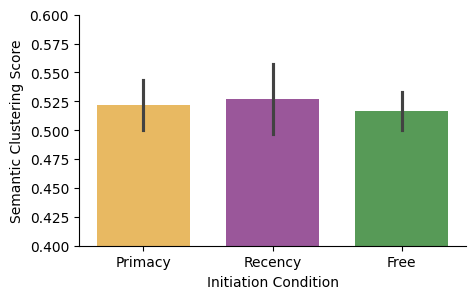

In [111]:
scl_df = scl.scl(filtered_df, wordpool, w2v_scores)
scl.plot_scl(scl_df, path="figures/11d_scl_by_condition.pdf")

In [112]:
stat_tests.one_sample(scl_df, ["scl"], popmean=0.5)

,initiation_condition,measure,test,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,primacy,scl,one_sample,12,1.952912,0.076736,11,0.563757,0.181174
1,recency,scl,one_sample,8,1.761502,0.121535,7,0.622785,0.181174
2,free,scl,one_sample,16,2.030797,0.060391,15,0.507699,0.181174


In [113]:
# 3) stats
stat_tests.condition_contrast(scl_df, ["scl"], paired=False)

,measure,test,contrast,n_1,n_2,n,t_stat,p_val,dof,cohen_d,p_val_holm
0,scl,welch,primacy vs free,12,16,12,0.367731,0.716664,21.530280,0.143813,1.0
1,scl,welch,recency vs free,8,16,8,0.600448,0.560252,11.114411,0.286490,1.0
2,scl,welch,primacy vs recency,12,8,8,-0.283807,0.780765,13.821979,-0.132909,1.0
